In [ ]:
import torch
from torch import nn

torch.__version__

In [ ]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pathlib
save_path = pathlib.Path("/content/drive/MyDrive/cv_data/cifar10_custom")
save_path.mkdir(parents=True, exist_ok=True)

In [5]:
import torchvision.datasets as datasets
print('downloading....')
train_data = datasets.CIFAR10(root='temp',train=True,download=True)
test_data = datasets.CIFAR10(root='temp',train=False,download=True)

downloading....


100%|██████████| 170M/170M [00:04<00:00, 37.6MB/s]


In [6]:
train_data,test_data

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: temp
     Split: Train,
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: temp
     Split: Test)

In [7]:
train_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [8]:
train_data.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

frog


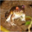

In [9]:
print(train_data.classes[train_data[0][1]])
train_data[0][0]


In [10]:
import os
import pathlib
import shutil

# 1. Define our path
data_path = pathlib.Path("data/cifar_custom")

# 2. Start fresh: if the folder exists, delete it and recreate it
if data_path.is_dir():
    shutil.rmtree(data_path)

# 3. Create the structure for our 3 chosen classes
target_classes = ["airplane", "dog", "cat"]
for split in ["train", "test"]:
    for cls in target_classes:
        (data_path / split / cls).mkdir(parents=True, exist_ok=True)

print(f"Clean folders created at: {data_path}")

Clean folders created at: data/cifar_custom


In [11]:
import torchvision
from PIL import Image

# 1. Load the raw data from 'temp' (where you downloaded it earlier)
train_set = torchvision.datasets.CIFAR10(root="temp", train=True, download=False)
test_set = torchvision.datasets.CIFAR10(root="temp", train=False, download=False)

def extract(dataset, split_name):
    print(f"Extracting {split_name}...")
    for i, (img, label_idx) in enumerate(dataset):
        class_name = dataset.classes[label_idx]
        if class_name in target_classes:
            # Save to: data/cifar_custom/train/dog/123.jpg
            save_path = data_path / split_name / class_name / f"{i}.jpg"
            img.save(save_path)

extract(train_set, "train")
extract(test_set, "test")

Extracting train...
Extracting test...


In [12]:
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        if len(filenames) > 0:
            print(f"Found {len(filenames)} images in '{dirpath}'")

walk_through_dir("data/cifar_custom")

Found 5000 images in 'data/cifar_custom/train/cat'
Found 5000 images in 'data/cifar_custom/train/dog'
Found 5000 images in 'data/cifar_custom/train/airplane'
Found 1000 images in 'data/cifar_custom/test/cat'
Found 1000 images in 'data/cifar_custom/test/dog'
Found 1000 images in 'data/cifar_custom/test/airplane'


Data preparation

In [13]:
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        # TASK: Print the number of images in each folder
        # Hint: Use len(filenames) to get the count
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

# Now call the function on your data folder
walk_through_dir("data/cifar_custom")

There are 2 directories and 0 images in 'data/cifar_custom'.
There are 3 directories and 0 images in 'data/cifar_custom/train'.
There are 0 directories and 5000 images in 'data/cifar_custom/train/cat'.
There are 0 directories and 5000 images in 'data/cifar_custom/train/dog'.
There are 0 directories and 5000 images in 'data/cifar_custom/train/airplane'.
There are 3 directories and 0 images in 'data/cifar_custom/test'.
There are 0 directories and 1000 images in 'data/cifar_custom/test/cat'.
There are 0 directories and 1000 images in 'data/cifar_custom/test/dog'.
There are 0 directories and 1000 images in 'data/cifar_custom/test/airplane'.


In [14]:
train_dir = "data/cifar_custom/train"
test_dir = "data/cifar_custom/test"

train_dir,test_dir

('data/cifar_custom/train', 'data/cifar_custom/test')

class name is the folder name in this situation

In [15]:
data_path

PosixPath('data/cifar_custom')

In [16]:

image_path_list=list(data_path.glob("*/*/*.jpg"))

image_path_list[:10]

[PosixPath('data/cifar_custom/train/cat/14014.jpg'),
 PosixPath('data/cifar_custom/train/cat/21835.jpg'),
 PosixPath('data/cifar_custom/train/cat/10558.jpg'),
 PosixPath('data/cifar_custom/train/cat/8943.jpg'),
 PosixPath('data/cifar_custom/train/cat/4174.jpg'),
 PosixPath('data/cifar_custom/train/cat/47788.jpg'),
 PosixPath('data/cifar_custom/train/cat/13653.jpg'),
 PosixPath('data/cifar_custom/train/cat/22253.jpg'),
 PosixPath('data/cifar_custom/train/cat/23270.jpg'),
 PosixPath('data/cifar_custom/train/cat/41369.jpg')]

In [17]:
import random

random.seed(42)

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem
random_image_path,image_class

(PosixPath('data/cifar_custom/train/cat/36761.jpg'), 'cat')

cat
(32, 32)


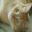

In [18]:
image = Image.open(random_image_path)
print(image_class)
print(image.size)
image

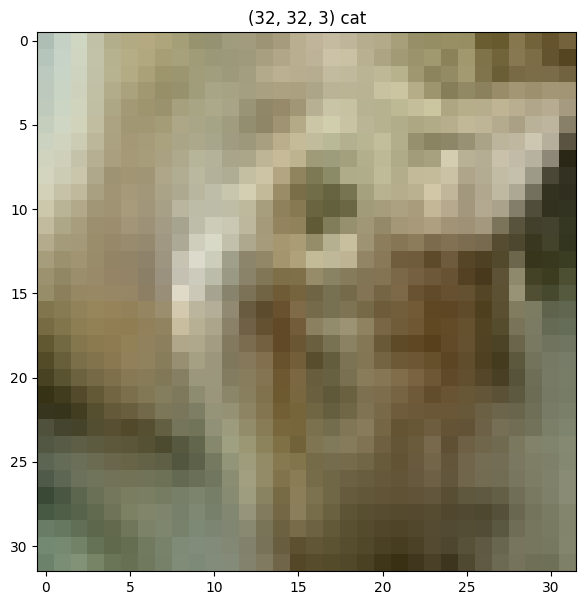

In [19]:
import numpy as np
import matplotlib.pyplot as plt

ar_image = np.asarray(image)
plt.figure(figsize=(10,7))
plt.title(f'{ar_image.shape} {image_class}')
plt.imshow(ar_image)

array([[[174, 190, 180],
        [197, 209, 197],
        [207, 215, 194],
        ...,
        [114,  99,  58],
        [101,  83,  45],
        [116,  98,  60]],

       [[181, 197, 187],
        [199, 211, 199],
        [208, 213, 193],
        ...,
        [124, 109,  70],
        [ 99,  83,  47],
        [ 85,  69,  33]],

       [[188, 201, 191],
        [200, 212, 198],
        [206, 211, 191],
        ...,
        [123, 109,  72],
        [122, 108,  73],
        [113,  99,  64]],

       ...,

       [[105, 124, 102],
        [102, 120,  96],
        [ 97, 111,  86],
        ...,
        [118, 118,  94],
        [120, 122,  98],
        [130, 132, 108]],

       [[115, 137, 114],
        [118, 138, 113],
        [114, 130, 103],
        ...,
        [118, 118,  94],
        [118, 120,  96],
        [131, 133, 109]],

       [[108, 130, 107],
        [122, 142, 117],
        [130, 146, 119],
        ...,
        [111, 111,  87],
        [110, 112,  88],
        [126, 128, 104]]], dtype=uint8)
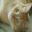

In [20]:
ar_image

In [21]:
# Transforming data to tensors
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [22]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

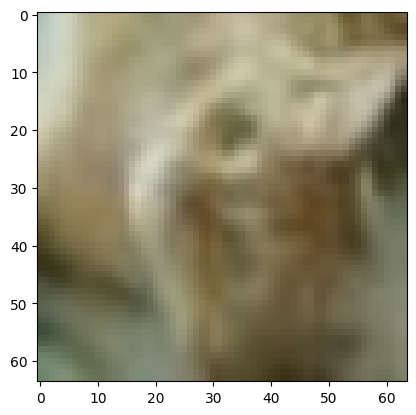

In [23]:
n = data_transform(image)
m =n.permute(1,2,0)
plt.imshow(m)

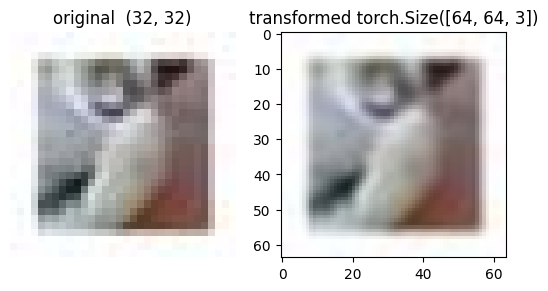

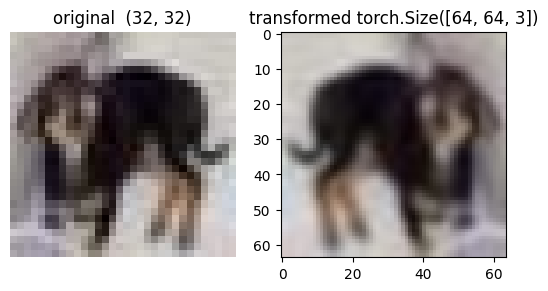

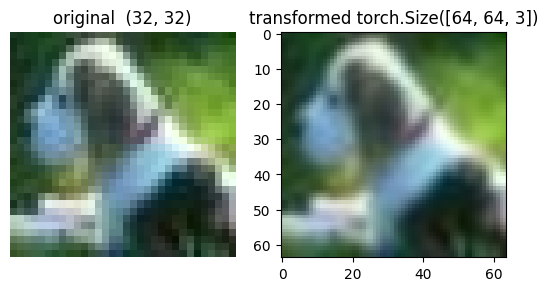

In [24]:
def plot_transform(image_path,transforms,n=3,seed=None):
  if seed:
    random.seed(seed)
  random_image_path = random.sample(image_path_list,k=n)
  for image_path in random_image_path:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f'original  {f.size}')
      ax[0].axis(False)

      transformed_image = transforms(f)
      transformed_image = transformed_image.permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f'transformed {transformed_image.shape}')
      ax[0].axis(False)


plot_transform(image_path=image_path_list,transforms=data_transform,n=3)


Loading

# image folder or custom loader build by us

In [25]:
# imagefolder
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,transform=data_transform,target_transform=None)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 15000
     Root location: data/cifar_custom/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 3000
     Root location: data/cifar_custom/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [26]:
class_name = train_data.classes
class_name

['airplane', 'cat', 'dog']

In [27]:
img,label= train_data[0][0], train_data[0][1]

In [28]:
img.shape

torch.Size([3, 64, 64])

In [29]:
class_name[label]

'airplane'

In [30]:
img.dtype

torch.float32

In [31]:
os.cpu_count()

2

In [32]:
# turn data into itterables and batches
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=os.cpu_count(),
                              #pin_memory=True
                              )

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                              shuffle=False,
                              num_workers=os.cpu_count(),
                            )

train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7f925020dd60>,
 <torch.utils.data.dataloader.DataLoader at 0x7f92504e5c40>)

In [33]:
next(iter(train_dataloader))[1]

tensor([1, 0, 2, 0, 0, 1, 1, 0, 0, 2, 1, 2, 0, 2, 1, 0, 1, 2, 1, 1, 0, 0, 2, 1,
        0, 0, 2, 2, 0, 1, 0, 1])

In [34]:
len(train_dataloader)

469

In [35]:
469*32


15008

In [36]:
img, label = next(iter(train_dataloader))
img.shape,label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [37]:
#Other than ImageFolder option, Manual way
#will work with anything, ni pytorch datasets needed
# Big risk though, prone to errors

import os
import pathlib
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [38]:
train_data.classes, train_data.class_to_idx

(['airplane', 'cat', 'dog'], {'airplane': 0, 'cat': 1, 'dog': 2})

subclassing the Dataset abstract

In [39]:
target_directory = train_dir
print(target_directory)

data/cifar_custom/train


In [40]:
o = os.scandir(target_directory)
list1 = [e.name for e in o] #list
list2 = [e.name for e in o] #empty

o = list(os.scandir(target_directory))
list1 = [e.name for e in o] #list
list2 = [e.name for e in o] #list
list1,list2


(['cat', 'dog', 'airplane'], ['cat', 'dog', 'airplane'])

In [41]:
class_name_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_name_found

['airplane', 'cat', 'dog']

In [42]:
def find_class(directory: str) -> Tuple[List[str], Dict[str, int]]:
  ''' Finds class from folder names'''
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

  class_to_idx = {classs:i for i,classs  in enumerate(classes)}
  return classes, class_to_idx

find_class(train_dir)


(['airplane', 'cat', 'dog'], {'airplane': 0, 'cat': 1, 'dog': 2})

In [43]:
class CustomImageDataset(Dataset):
  def __init__(self,targ_dir: str, transform=None):
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    self.transform = transform
    self.classes, self.class_to_idx = find_class(targ_dir)
    self.class_idxs = [
        self.class_to_idx[path.parent.name]
        for path in self.paths
    ]

  def load_image(self, index: int) -> Image.Image:
    "Opens an image via a path and returns it."
    image_path = self.paths[index]
    return Image.open(image_path)

  def __len__(self):
    return len(self.paths)

  def __getitem__(self, index) -> Tuple[torch.Tensor, int]:

    #  img = self.load_image(index)
    #  class_name = self.paths[index].parent.name  # we did it here i think it is better to identify it in init so it doesn't recompute
    #  class_idx = self.class_to_idx[class_name]

    #  if self.transform:
    #   return self.transform(img), class_idx
    #  else:
    #   return img, class_idx
    img = self.load_image(index)

    # old way (you had this)
    # class_name = self.paths[index].parent.name
    # class_idx = self.class_to_idx[class_name]

    # improved (same result, faster)
    class_idx = self.class_idxs[index]

    if self.transform:
      img = self.transform(img)

    return img, class_idx



In [44]:
data_transform_train = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()])

data_transform_test = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()])


In [45]:
train_data_custom = CustomImageDataset(targ_dir=train_dir, transform=data_transform_train)
test_data_custom = CustomImageDataset(targ_dir=test_dir, transform=data_transform_test)

In [46]:
train_data_custom[0][1]

1

In [47]:
len(test_data),len(test_data_custom)

(3000, 3000)

In [48]:
train_data_custom.class_to_idx

{'airplane': 0, 'cat': 1, 'dog': 2}

In [49]:
train_data_custom.classes==train_data.classes

True

In [50]:
train_data_custom[0][0].shape

torch.Size([3, 64, 64])

In [51]:
len(train_data_custom)

15000

In [52]:
from torch.utils.data import Subset
indices = random.sample(range(len(train_data_custom)),k=2)
subset = Subset(train_data_custom, indices)
subset[0]

(tensor([[[0.7098, 0.6078, 0.4000,  ..., 0.7843, 0.9294, 1.0000],
          [0.5922, 0.5059, 0.3255,  ..., 0.7098, 0.8667, 0.9412],
          [0.3569, 0.2980, 0.1725,  ..., 0.5647, 0.7373, 0.8275],
          ...,
          [0.9255, 0.8902, 0.8157,  ..., 0.7804, 0.8627, 0.9020],
          [0.9765, 0.9647, 0.9373,  ..., 0.8667, 0.9294, 0.9608],
          [1.0000, 1.0000, 1.0000,  ..., 0.9098, 0.9608, 0.9882]],
 
         [[0.7137, 0.6118, 0.4039,  ..., 0.7608, 0.9216, 1.0000],
          [0.5922, 0.5059, 0.3255,  ..., 0.6863, 0.8549, 0.9373],
          [0.3529, 0.2902, 0.1686,  ..., 0.5373, 0.7176, 0.8078],
          ...,
          [0.7882, 0.7490, 0.6706,  ..., 0.7725, 0.8549, 0.8980],
          [0.9020, 0.8824, 0.8392,  ..., 0.8588, 0.9216, 0.9490],
          [0.9608, 0.9490, 0.9216,  ..., 0.9020, 0.9529, 0.9765]],
 
         [[0.6510, 0.5490, 0.3412,  ..., 0.6980, 0.8510, 0.9255],
          [0.5333, 0.4471, 0.2667,  ..., 0.6235, 0.7843, 0.8627],
          [0.2980, 0.2392, 0.1216,  ...,

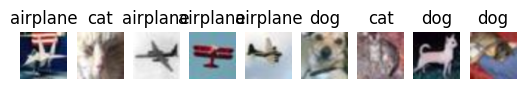

In [53]:
def visualize(dataset: torch.utils.data.Dataset,
              classes: List[str] = None,
              n=9,
              seed: int = None):

  if seed:
    random.seed(seed)

  random_samples_idx = random.sample(range(len(dataset)),k=n)
  for i,idx in enumerate(random_samples_idx):
    image, label = dataset[idx][0], dataset[idx][1]
    plt.subplot(1,n,i+1)
    plt.imshow(image.permute(1,2,0))
    if classes:
      plt.title(classes[label])
    else:
      plt.title(label)
    plt.axis(False)

visualize(train_data_custom,class_name)







In [54]:
from torch.utils.data import DataLoader

BATCH_SIZE=32

train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers=os.cpu_count(),
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    num_workers=os.cpu_count())

In [55]:
img, label = next(iter(train_dataloader_custom))
img.shape,label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

Data augmentation

In [56]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [57]:
image_path_list = list(data_path.glob('*/*/*.jpg'))
image_path_list[:10]

[PosixPath('data/cifar_custom/train/cat/14014.jpg'),
 PosixPath('data/cifar_custom/train/cat/21835.jpg'),
 PosixPath('data/cifar_custom/train/cat/10558.jpg'),
 PosixPath('data/cifar_custom/train/cat/8943.jpg'),
 PosixPath('data/cifar_custom/train/cat/4174.jpg'),
 PosixPath('data/cifar_custom/train/cat/47788.jpg'),
 PosixPath('data/cifar_custom/train/cat/13653.jpg'),
 PosixPath('data/cifar_custom/train/cat/22253.jpg'),
 PosixPath('data/cifar_custom/train/cat/23270.jpg'),
 PosixPath('data/cifar_custom/train/cat/41369.jpg')]

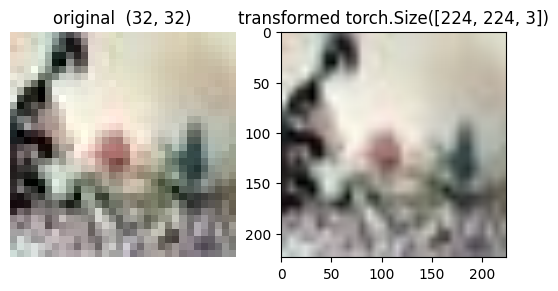

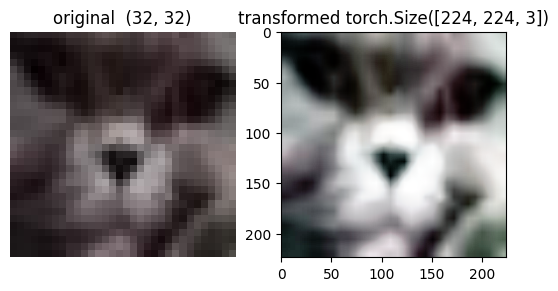

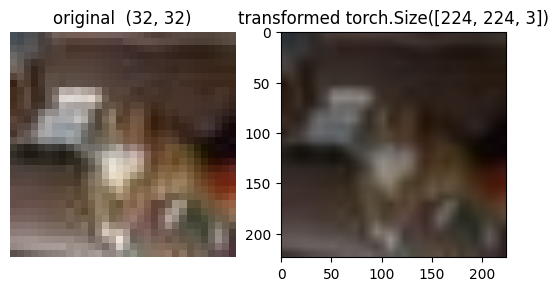

In [58]:
plot_transform(image_path=image_path_list,transforms=train_transform,n=3)

Model: TinyVGG

In [59]:
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [60]:
from torchvision import datasets

train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

In [61]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size= BATCH_SIZE,
                                     shuffle = True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    shuffle = False,
                                    num_workers=NUM_WORKERS)

In [62]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*16*16,
                  out_features=output_shape)
    )
  def forward(self, x):
    # x = self.conv_block_1(x)
    # x = self.conv_block_2(x)
    # x= self.classifier(x)
    # return x
    return self.classifier(self.conv_block_2(self.conv_block_1(x))) # Same as before check operator fusion to make it faster


In [63]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(class_name)).to(device)

In [64]:
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [65]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [66]:
model_0(image_batch.to(device))

tensor([[0.0635, 0.0621, 0.0372],
        [0.0589, 0.0599, 0.0401],
        [0.0626, 0.0637, 0.0355],
        [0.0569, 0.0568, 0.0381],
        [0.0640, 0.0616, 0.0382],
        [0.0714, 0.0652, 0.0398],
        [0.0651, 0.0609, 0.0368],
        [0.0688, 0.0629, 0.0376],
        [0.0654, 0.0642, 0.0367],
        [0.0654, 0.0609, 0.0385],
        [0.0581, 0.0596, 0.0364],
        [0.0584, 0.0607, 0.0374],
        [0.0644, 0.0651, 0.0411],
        [0.0620, 0.0629, 0.0371],
        [0.0615, 0.0589, 0.0367],
        [0.0649, 0.0655, 0.0365],
        [0.0640, 0.0663, 0.0350],
        [0.0610, 0.0639, 0.0401],
        [0.0598, 0.0605, 0.0384],
        [0.0636, 0.0641, 0.0388],
        [0.0584, 0.0597, 0.0378],
        [0.0617, 0.0618, 0.0353],
        [0.0546, 0.0536, 0.0366],
        [0.0585, 0.0583, 0.0346],
        [0.0683, 0.0670, 0.0382],
        [0.0622, 0.0602, 0.0355],
        [0.0681, 0.0657, 0.0388],
        [0.0591, 0.0602, 0.0406],
        [0.0578, 0.0557, 0.0352],
        [0.058

In [67]:
!pip install torchinfo

In [68]:
from torchinfo import summary

summary(model=model_0, input_size=[32,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

In [69]:
def train_step(model: torch.nn.Module,
               dataloader: DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  model.train()
  train_loss,train_acc = 0,0
  for batch, (X, y) in enumerate(tqdm(dataloader, desc="Training Batches")):
    X,y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred,y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc += (y_pred_class==y).sum().item()/len(y_pred)

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  return train_loss, train_acc


In [70]:
def test_step(model: torch.nn.Module,
              dataloader: DataLoader,
              loss_fn: torch.nn.Module):
  model.eval()
  test_loss, test_acc = 0,0
  with torch.inference_mode():
    for batch, (X,y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits,y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += (test_pred_labels==y).sum().item()/len(test_pred_labels)

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  return test_loss, test_acc


In [71]:
from tqdm.auto import tqdm



In [72]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device):

  results = {'train_loss' : [],
             'train_acc': [],
             'test_loss' : [],
             'test_acc': []}

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model_0,
               dataloader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer)
    test_loss, test_acc = test_step(model=model_0,
                                    dataloader = test_dataloader,
                                    loss_fn = loss_fn)
    print(f' {epoch} | train_loss  {train_loss} | train_acc {train_acc} | test_loss {test_loss} | test_acc {test_acc}')
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

  return results


In [73]:
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

In [74]:

model_0_results = train(model=model_0,
                        train_dataloader= train_dataloader_simple,
                        test_dataloader= test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 0 | train_loss  0.8126311729203409 | train_acc 0.5822894456289979 | test_loss 0.7300600564860283 | test_acc 0.613031914893617


Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 1 | train_loss  0.6861397488666242 | train_acc 0.658204513148543 | test_loss 0.6709277395238268 | test_acc 0.6805186170212766


...

 7 | train_loss  0.5404773234431424 | train_acc 0.750044420753376 | test_loss 0.5596774989303123 | test_acc 0.745456560283688


Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 8 | train_loss  0.5194787693176188 | train_acc 0.7630152807391614 | test_loss 0.5682544662280286 | test_acc 0.745456560283688


Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 9 | train_loss  0.5060108582665925 | train_acc 0.7723658493248045 | test_loss 0.5529773496883981 | test_acc 0.7511081560283689


In [75]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [76]:
import matplotlib.pyplot as plt


In [77]:
def plot_loss_curves(results):
  loss = results['train_loss']
  test_loss = results['test_loss']

  accuracy = results['train_acc']
  test_accuracy = results['test_acc']

  epchs = range(len(results['train_loss']))

  plt.figure(figsize=(15,7))
  plt.subplot(1,2,1)
  plt.plot(epchs,loss,label='train_loss')
  plt.plot(epchs,test_loss,label='test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epchs,accuracy,label='train_accuracy')
  plt.plot(epchs,test_accuracy,label='test_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()




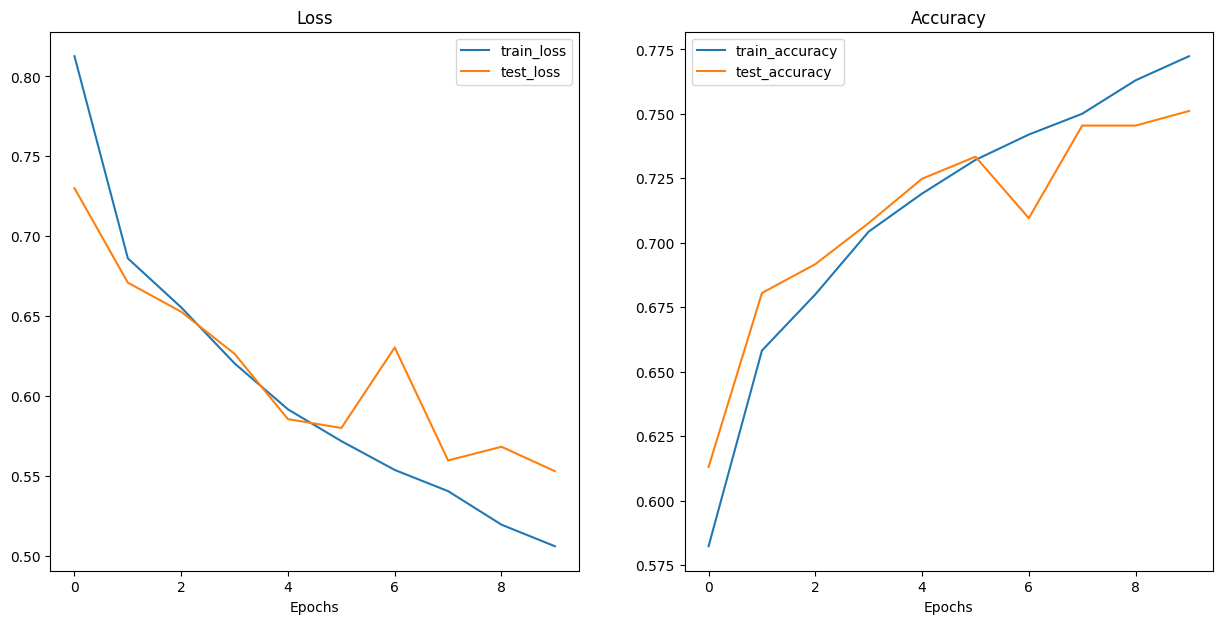

In [78]:
plot_loss_curves(model_0_results)

overfitting

In [79]:
train_transform_trivial = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform_simple = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [80]:
from torchvision import datasets

train_data_trivial = datasets.ImageFolder(root=train_dir,
                                          transform=train_transform_trivial)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=test_transform_simple)

In [81]:
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataloader_trivial = DataLoader(dataset=train_data_trivial,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS,
                                      persistent_workers=True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS,
                                    persistent_workers=True)


In [82]:
import copy
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device=device,
          patiance = 5,
          scheduler = None):
  best_test_loss = float('inf')
  epochs_without_improvement = 0
  best_model_weights = copy.deepcopy(model.state_dict())


  results = {'train_loss' : [],
             'train_acc': [],
             'test_loss' : [],
             'test_acc': []}

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
               dataloader = train_dataloader,
               loss_fn = loss_fn,
               optimizer = optimizer)
    test_loss, test_acc = test_step(model=model,
                                    dataloader = test_dataloader,
                                    loss_fn = loss_fn)
    print(f' {epoch} | train_loss  {train_loss} | train_acc {train_acc} | test_loss {test_loss} | test_acc {test_acc}')
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

    if scheduler is not None:
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(test_loss) # Plateau scheduler needs the test_loss
        else:
            scheduler.step()
    if test_loss < best_test_loss:
      best_test_loss = test_loss
      epchs_without_improvements = 0
      best_model_weights = copy.deepcopy(model.state_dict())

    else:
      epochs_without_improvement += 1
      if epochs_without_improvement >= patiance:
        print(f'Early stopping at epoch {epoch}')
        break

  model.load_state_dict(best_model_weights)
  return results


In [87]:
model_1 = TinyVGG(input_shape=3,
                  hidden_units=64,
                  output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(params=model_1.parameters(),
                             lr=0.001,
                              weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode='min',
                                                       factor=0.5,
                                                       patience=3)

In [88]:
if __name__ == '__main__':
  model_1_results = train(model = model_1,
                          train_dataloader = train_dataloader_trivial,
                          test_dataloader = test_dataloader_simple,
                          optimizer =  optimizer,
                          loss_fn = loss_fn,
                          epochs = 50,
                          patiance = 5,
                          scheduler = scheduler)

  0%|          | 0/50 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 0 | train_loss  0.9016817988617334 | train_acc 0.5398232054015636 | test_loss 0.701530432447474 | test_acc 0.6467198581560284


Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 1 | train_loss  0.7578667840088354 | train_acc 0.6237117981520967 | test_loss 0.640581413627939 | test_acc 0.6880540780141844


...

 12 | train_loss  0.5575261307296469 | train_acc 0.7503331556503199 | test_loss 0.46796449709762916 | test_acc 0.7946586879432624


Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 13 | train_loss  0.5536985282958952 | train_acc 0.7542643923240938 | test_loss 0.47239752149486797 | test_acc 0.7896719858156029


Training Batches:   0%|          | 0/469 [00:00<?, ?it/s]

 14 | train_loss  0.5398132487146585 | train_acc 0.7601723525230988 | test_loss 0.47033289225494607 | test_acc 0.7948803191489362
Early stopping at epoch 14


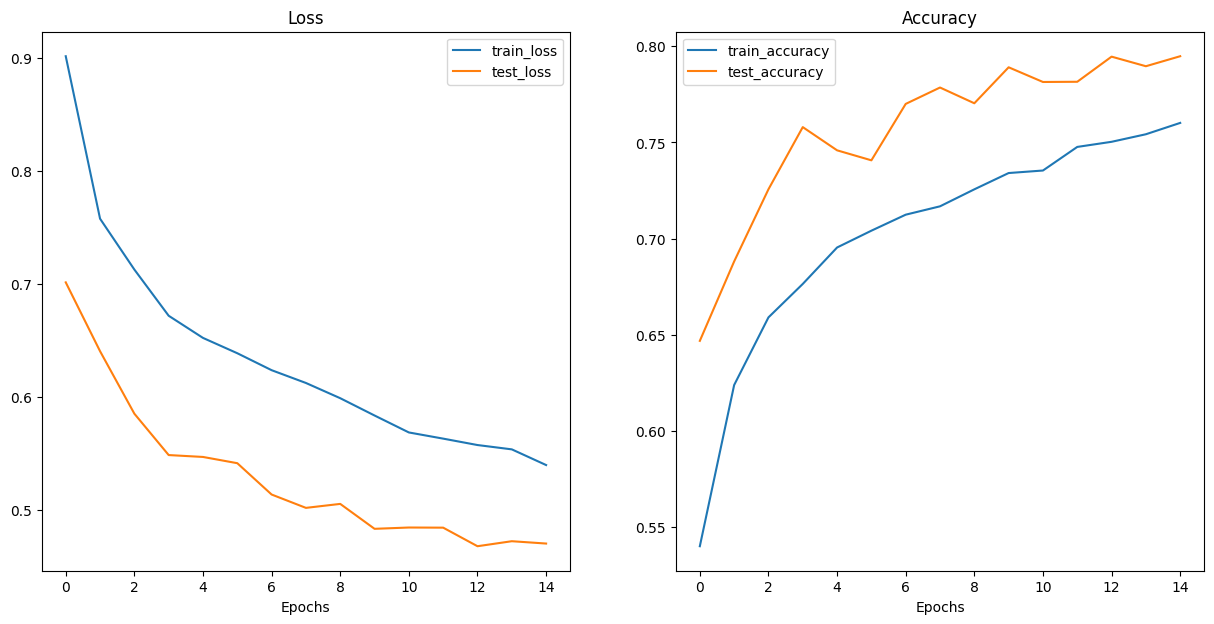

In [89]:
plot_loss_curves(model_1_results)

In [92]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df[:5],model_1_df[:5]

(   train_loss  train_acc  test_loss  test_acc
 0    0.812631   0.582289   0.730060  0.613032
 1    0.686140   0.658205   0.670928  0.680519
 2    0.655432   0.679971   0.652712  0.691711
 3    0.620406   0.704335   0.626375  0.707668
 4    0.591644   0.719083   0.585527  0.724845,
    train_loss  train_acc  test_loss  test_acc
 0    0.901682   0.539823   0.701530  0.646720
 1    0.757867   0.623712   0.640581  0.688054
 2    0.712854   0.658937   0.585272  0.725621
 3    0.671959   0.676350   0.548655  0.757979
 4    0.652350   0.695318   0.546981  0.745900)

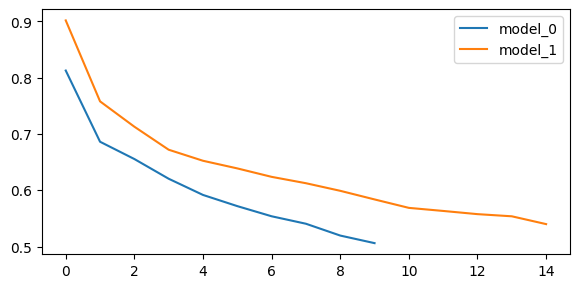

In [97]:
plt.figure(figsize=(15,7))
epchs = range(len(model_0_df))
epchs1 = range(len(model_1_df))
plt.subplot(2,2,1)
plt.plot(epchs, model_0_df["train_loss"],label="model_0")
plt.plot(epchs1, model_1_df["train_loss"],label="model_1")
plt.legend()


Let's make a prediction

Image already exists at data/cat.jpeg


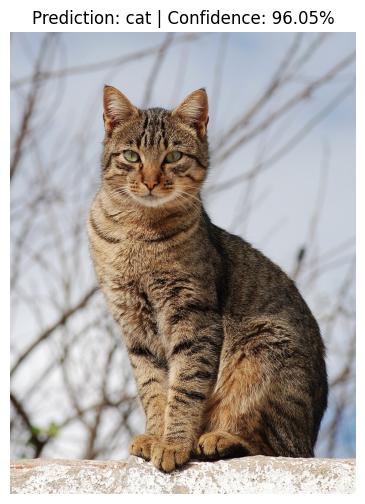

In [108]:
import requests
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. Download the Image (with Bot Disguise) ---
data_path = Path("data")
data_path.mkdir(parents=True, exist_ok=True)
custom_image_path = data_path / 'cat.jpeg'

# If the file doesn't exist, download it
if not custom_image_path.is_file():
    url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/960px-Cat_November_2010-1a.jpg"

    # The User-Agent header bypasses the bot protection
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

    print(f"Downloading image from {url}...")
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        with open(custom_image_path, 'wb') as f:
            f.write(response.content)
        print("Successfully downloaded the real image!")
    else:
        print(f"Failed to download. The server responded with status code: {response.status_code}")
else:
    print(f"Image already exists at {custom_image_path}")

# --- 2. Load and Preprocess ---
try:
    # Open the image using PIL and ensure it's RGB
    custom_image = Image.open(custom_image_path).convert("RGB")

    # Transform it to exactly match the CIFAR-10 format your model learned
    custom_transform = transforms.Compose([
        transforms.Resize((64, 64)), # TinyVGG expects 64x64!
        transforms.ToTensor()
    ])

    # Apply transform: shape becomes [Channels, Height, Width] ->
    img_tensor = custom_transform(custom_image)

    # Add batch dimension: shape becomes [Batch, Channels, Height, Width] ->
    # Also move it to the same device (GPU/CPU) as your model
    img_batch = img_tensor.unsqueeze(dim=0).to(device)

    # --- 3. Run Inference ---
    # Put the model in evaluation mode
    model_1.eval()


    with torch.inference_mode():
        # Pass the batched image through the model
        raw_logits = model_1(img_batch)

        # Convert raw logits to probabilities
        pred_probs = torch.softmax(raw_logits, dim=1)

        # Get the index of the highest probability
        pred_label = torch.argmax(pred_probs, dim=1).item()

    # Map the index to the actual class string
    class_names = train_data.classes
    predicted_class = class_names[pred_label]
    prediction_confidence = pred_probs[0][pred_label].item()

    # --- 4. Visualize ---
    # We show the original high-res image, but the model actually "saw" a 32x32 version
    plt.figure(figsize=(6, 6))
    plt.imshow(custom_image)
    plt.title(f"Prediction: {predicted_class} | Confidence: {prediction_confidence*100:.2f}%")
    plt.axis(False)
    plt.show()

except Exception as e:
    print(f"An error occurred while processing the image: {e}")

In [ ]:
# Save the weights to a file
torch.save(model_1.state_dict(), data_path / "tinyvgg_cifar10_best_model.pth")
print("Model parameters saved!")

# (For later) How you would load them back in tomorrow:
# loaded_model = TinyVGG(input_shape=3, hidden_units=32, output_shape=3).to(device)
# loaded_model.load_state_dict(torch.load(data_path / "tinyvgg_cifar10_best_model.pth"))